# CVXPY para Otimização Convexa e Portfólios

## 1 - Importar dependências

In [28]:
# ! pip install numpy
# ! pip install pandas
# ! pip install cvxpy
# ! pip install matplotlib

In [29]:
import numpy as np
import pandas as pd
import cvxpy as cp
import matplotlib.pyplot as plt

np.random.seed(42)


## 2 - Exemplo de aplicação em MQO

In [30]:
""" Mínimos Quadrados Ordinários"""

# Dados meteorológicos (simulados)
days, cities = 30, 5
umidity = 100*np.random.rand(days, cities)
x_true = np.array([1.5, 2.0, 0.5, 0.0, 3.0])
prec_vol = umidity @ x_true + 0.2 * np.random.randn(days)
prec_vol = np.where(prec_vol < 0, 0, prec_vol)

# Definição da variável e objetivo
x = cp.Variable(5) # Variável de decisão
cost = cp.sum_squares(umidity @ x - prec_vol) # Custo
objective = cp.Minimize(cost) # Objetivo
problem = cp.Problem(objective) # Problema, é definido com base no objetivo e restrições
problem.solve()

print("status:", problem.status)
print("x estimado:", x.value)
print("x verdadeiro:", x_true)
print("erro norm:", np.linalg.norm(x.value - x_true))

residual = umidity @ x.value - prec_vol
print("norma do residual:", np.linalg.norm(residual))
print("primeiros 5 resíduos:", residual[:5])

status: optimal
x estimado: [1.50017760e+00 1.99967054e+00 4.99316838e-01 4.71286550e-04
 3.00004091e+00]
x verdadeiro: [1.5 2.  0.5 0.  3. ]
erro norm: 0.0009113605502751438
norma do residual: 1.0728137968773819
primeiros 5 resíduos: [-0.00735257 -0.08739999 -0.07076452  0.2126685  -0.22311999]


## 3 - Comparando diferentes abordagens

In [31]:
""" Dados sintéticos """

# Simulando retornos e variância de 6 ativos
n_assets = 6
assets = [f"A{i+1}" for i in range(n_assets)]
mu = np.array([0.12, 0.10, 0.14, 0.08, 0.11, 0.09]) # Retornos estimados
X = np.random.randn(n_assets, n_assets)
Sigma = X.T @ X / 10 + 0.02 * np.eye(n_assets) # Variância estimada
rf = 0.03 # Taxa livre de risco

print("retornos esperados:", mu)
print("matriz de covariância:\n", Sigma)

retornos esperados: [0.12 0.1  0.14 0.08 0.11 0.09]
matriz de covariância:
 [[ 5.29051710e-01  6.37023484e-02 -1.37647014e-01  2.02061074e-01
  -7.11353026e-02  4.23331078e-01]
 [ 6.37023484e-02  3.08166080e-01 -1.87656013e-01  8.37680158e-02
  -7.87691566e-02  7.93925563e-02]
 [-1.37647014e-01 -1.87656013e-01  5.33118324e-01  1.83548389e-01
   1.17332434e-01  7.39997403e-02]
 [ 2.02061074e-01  8.37680158e-02  1.83548389e-01  5.37730592e-01
  -1.24352140e-01  4.41720036e-01]
 [-7.11353026e-02 -7.87691566e-02  1.17332434e-01 -1.24352140e-01
   2.26008965e-01 -8.44184289e-04]
 [ 4.23331078e-01  7.93925563e-02  7.39997403e-02  4.41720036e-01
  -8.44184289e-04  1.25315286e+00]]


In [32]:
""" Métodos para visualização"""

def portfolio_stats(w, mu, Sigma, rf=0.03):
    ret = float(mu @ w) # Retorno do portfólio
    vol = float(np.sqrt(w.T @ Sigma @ w)) # Volatilidade do portfólio
    sharpe = (ret - rf) / vol if vol > 0 else np.nan # Sharpe com base no retorno
    return ret, vol, sharpe
    

def show_weights(w, title="Pesos"):
    # Exibição organizada dos ativos
    df = pd.DataFrame({"asset": assets, "weight": np.round(w, 4)})
    print(title)
    display(df)

In [33]:
""" Carteira de mínima variância"""

w = cp.Variable(n_assets)
objective = cp.Minimize(cp.quad_form(w, Sigma))
constraints = [cp.sum(w) == 1, w >= 0]
prob = cp.Problem(objective, constraints)
prob.solve(solver=cp.OSQP)

w_minvar = w.value
show_weights(w_minvar, "Carteira de mínima variância")

ret, vol, sharpe = portfolio_stats(w_minvar, mu, Sigma, rf)
print("retorno:", ret)
print("volatilidade:", vol)
print("Sharpe:", sharpe)

Carteira de mínima variância


,asset,weight
0,A1,0.1541
1,A2,0.3428
2,A3,0.1950
3,A4,0.0000
4,A5,0.3082
5,A6,0.0000


retorno: 0.11396194791054129
volatilidade: 0.23361740355977906
Sharpe: 0.35939937107064346


In [34]:
""" Carteira de mínima variância com retorno alvo """

target_return = 0.11

w = cp.Variable(n_assets)
objective = cp.Minimize(cp.quad_form(w, Sigma))
constraints = [
    cp.sum(w) == 1,
    w >= 0,
    mu @ w >= target_return
]
prob = cp.Problem(objective, constraints)
prob.solve(solver=cp.OSQP)

w_mv = w.value
show_weights(w_mv, "Carteira de minima variância com retorno alvo")

ret, vol, sharpe = portfolio_stats(w_mv, mu, Sigma, rf)
print("retorno:", ret)
print("volatilidade:", vol)
print("Sharpe:", sharpe)

Carteira de minima variância com retorno alvo


,asset,weight
0,A1,0.1541
1,A2,0.3428
2,A3,0.1950
3,A4,0.0000
4,A5,0.3082
5,A6,0.0000


retorno: 0.11396194791054129
volatilidade: 0.23361740355977906
Sharpe: 0.35939937107064346


In [35]:
""" Carteira de máximo retorno com volatilidade limitada """

w = cp.Variable(n_assets)
excess_return = mu - rf

objective = cp.Maximize(excess_return @ w)
constraints = [
    cp.quad_form(w, Sigma) <= 0.5,
    cp.sum(w) == 1,
    w >= 0
]
prob = cp.Problem(objective, constraints)
prob.solve(solver=cp.SCS)

w_sharpe = w.value
show_weights(w_sharpe, "Carteira de máximo retorno")

ret, vol, sharpe = portfolio_stats(w_sharpe, mu, Sigma, rf)
print("retorno:", ret)
print("volatilidade:", vol)
print("Sharpe:", sharpe)

Carteira de máximo retorno


,asset,weight
0,A1,0.0253
1,A2,-0.0000
2,A3,0.9747
3,A4,-0.0000
4,A5,-0.0000
5,A6,-0.0000


retorno: 0.13949347378830776
volatilidade: 0.7071067917337079
Sharpe: 0.15484715331307738


In [36]:
""" Carteira com objetivo misto e restrição sobre grupo """

w = cp.Variable(n_assets)

constraints = [
    cp.sum(w) == 1,
    w >= 0,
    w <= 0.35

]

# Exemplo: limite de 50% em um subconjunto de ativos
constraints.append(cp.sum(w[[0, 2, 4]]) <= 0.50
                   )

objective = cp.Minimize(cp.quad_form(w, Sigma) - 1.5 * mu @ w)
prob = cp.Problem(objective, constraints)
prob.solve(solver=cp.OSQP)

w_constrained = w.value
show_weights(w_constrained, "Carteira com restrição sobre grupo")

ret, vol, sharpe = portfolio_stats(w_constrained, mu, Sigma, rf)
print("retorno:", ret)
print("volatilidade:", vol)
print("Sharpe:", sharpe)

Carteira com restrição sobre grupo


,asset,weight
0,A1,0.0579
1,A2,0.3500
2,A3,0.1265
3,A4,0.1500
4,A5,0.3157
5,A6,0.0000


retorno: 0.10637236703374042
volatilidade: 0.25194439080798126
Sharpe: 0.30313184107340346


,strategy,return,vol,sharpe
0,mínima variância,0.113962,0.233617,0.359399
1,retorno alvo,0.113962,0.233617,0.359399
2,máximo retorno,0.139493,0.707107,0.154847
3,grupo,0.106372,0.251944,0.303132


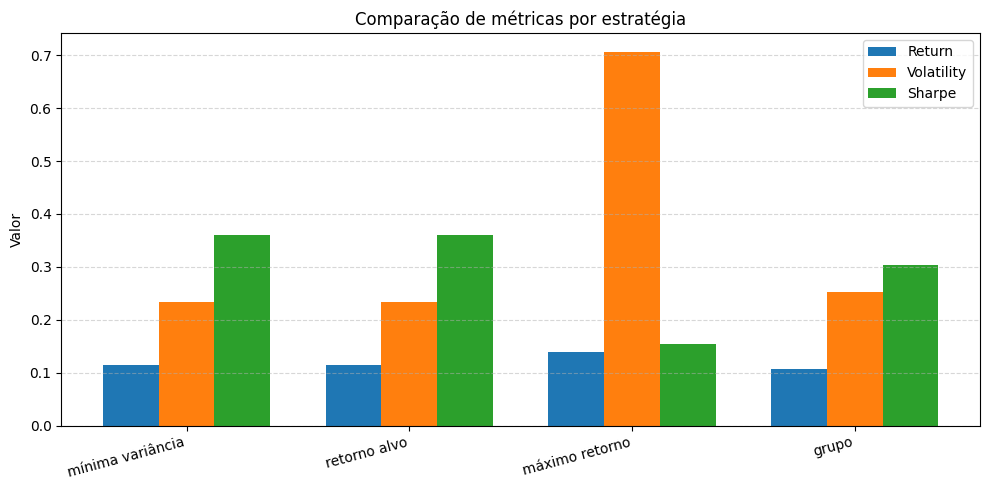

In [37]:
""" Comparando carteiras """

results = pd.DataFrame([
    ["mínima variância", *portfolio_stats(w_minvar, mu, Sigma, rf)],
    ["retorno alvo", *portfolio_stats(w_mv, mu, Sigma, rf)],
    ["máximo retorno", *portfolio_stats(w_sharpe, mu, Sigma, rf)],
    ["grupo", *portfolio_stats(w_constrained, mu, Sigma, rf)]
], columns=["strategy", "return", "vol", "sharpe"])

display(results)

plt.figure(figsize=(10, 5))

xx = np.arange(len(results))
width = 0.25

plt.bar(xx - width, results["return"], width, label="Return")
plt.bar(xx, results["vol"], width, label="Volatility")
plt.bar(xx + width, results["sharpe"], width, label="Sharpe")

plt.xticks(xx, results["strategy"], rotation=15, ha="right")
plt.ylabel("Valor")
plt.title("Comparação de métricas por estratégia")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


## 4 - Padronização

In [ ]:
""" Função geral para o problema de Markowitz """

def solve_markowitz(mu, Sigma, target=None, long_only=True):
    n = len(mu)
    w = cp.Variable(n)
    constraints = [cp.sum(w) == 1]
    if long_only:
        constraints.append(w >= 0)
    if target is not None:
        constraints.append(mu @ w >= target)
    objective = cp.Minimize(cp.quad_form(w, Sigma))
    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.OSQP)
    return w.value, prob.status